# What I tried before archetypal analysis

A record of the clustering methods I tried before landing on archetypal analysis (see Appendix II). I'm keeping this around, Thiago, because the story of *why* my final methodology looks the way it does is more honest than just showing you the thing that worked.

My starting intuition was to follow Reagan et al. (2016) as closely as I could. They used agglomerative hierarchical clustering with Ward's linkage on mean absolute distance to find six basic arc shapes across a corpus of novels. That felt like the right template: replicate the method on screenplays and see what falls out. This notebook walks through that attempt, what went wrong, and the increasingly desperate corrections I made before concluding that hard clustering is just the wrong tool for this data.

In [5]:
import sys
!{sys.executable} -m pip install --quiet seaborn scipy scikit-learn numpy pandas matplotlib umap-learn hdbscan tslearn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Section 1: Load and quick look

I load the 20-point emotional arc vectors from the arc generation pipeline. Each row is a film; columns w01–w20 are z-scored RoBERTa sentiment scores at equally-spaced narrative positions.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from scipy.stats import pearsonr, chi2_contingency
from sklearn.metrics import silhouette_score

# Paths
ARC_CSV      = "../data/processed/emotional_arcs.csv"
OUTPUT_DIR   = "../docs/thesis-outputs/"

ARC_COLS = [f"w{str(i).zfill(2)}" for i in range(1, 21)]  # w01 … w20

# Load
df = pd.read_csv(ARC_CSV)

# Derive decade
def year_to_decade(year):
    if   1980 <= year <= 1989: return "1980s"
    elif 1990 <= year <= 1999: return "1990s"
    elif 2000 <= year <= 2009: return "2000s"
    elif 2010 <= year <= 2019: return "2010s"
    elif 2020 <= year <= 2025: return "2020s"
    else: return "Other"

df["decade"]        = df["year"].apply(year_to_decade)
df["primary_genre"] = df["genre"].str.split("|").str[0]

# Validate
print(f"Corpus shape: {df.shape[0]} films × {df.shape[1]} columns")
print(f"Arc vector columns present: {all(c in df.columns for c in ARC_COLS)}")
print(f"Missing values in arc vectors: {df[ARC_COLS].isnull().sum().sum()}")

print("\nDecade distribution:")
decade_counts = df["decade"].value_counts().sort_index()
for decade, count in decade_counts.items():
    pct = count / len(df) * 100
    print(f"  {decade}: {count:4d}  ({pct:.1f}%)")

print("\nPrimary genre distribution (top 15):")
genre_counts = df["primary_genre"].value_counts().head(15)
for genre, count in genre_counts.items():
    pct = count / len(df) * 100
    print(f"  {genre:<20s}: {count:4d}  ({pct:.1f}%)")

Corpus shape: 1627 films × 26 columns
Arc vector columns present: True
Missing values in arc vectors: 0

Decade distribution:
  1980s:  214  (13.2%)
  1990s:  287  (17.6%)
  2000s:  310  (19.1%)
  2010s:  569  (35.0%)
  2020s:  247  (15.2%)

Primary genre distribution (top 15):
  Drama               :  449  (27.6%)
  Comedy              :  299  (18.4%)
  Action              :  178  (10.9%)
  Horror              :  144  (8.9%)
  Adventure           :  114  (7.0%)
  Crime               :   86  (5.3%)
  Thriller            :   72  (4.4%)
  Science Fiction     :   59  (3.6%)
  Fantasy             :   48  (3.0%)
  Animation           :   41  (2.5%)
  Romance             :   35  (2.2%)
  Mystery             :   24  (1.5%)
  History             :   22  (1.4%)
  Family              :   20  (1.2%)
  War                 :   13  (0.8%)


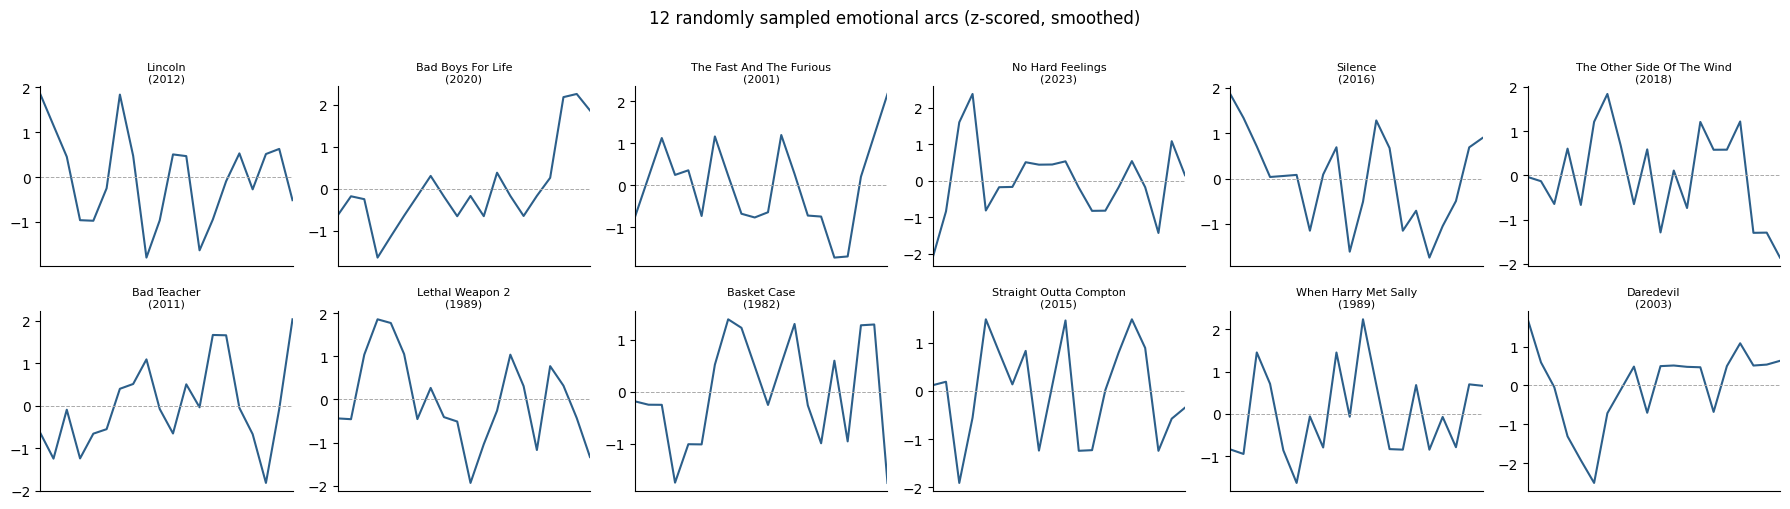

In [7]:
# Plot 12 randomly sampled arcs
rng = np.random.default_rng(seed=42)
sample_indices = rng.choice(len(df), size=12, replace=False)
sample_df = df.iloc[sample_indices]

x_positions = np.linspace(0, 1, 20)

fig, axes = plt.subplots(2, 6, figsize=(18, 5))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_df.iterrows()):
    arc_values = row[ARC_COLS].values.astype(float)
    ax.plot(x_positions, arc_values, color="#2C5F8A", linewidth=1.5)
    ax.axhline(0, color="#AAAAAA", linewidth=0.7, linestyle="--")
    ax.set_title(f"{row['title']}\n({int(row['year'])})", fontsize=8, pad=3)
    ax.set_xticks([])
    ax.set_xlim(0, 1)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("12 randomly sampled emotional arcs (z-scored, smoothed)", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}sample_arcs.png", dpi=150, bbox_inches="tight")
plt.show()

Fine. Twelve random arcs, all look like plausible sentiment trajectories. Nothing flat, nothing obviously broken upstream. Moving on.

## Section 2: Ward's hierarchical clustering

This is the Reagan et al. recipe. Compute pairwise mean absolute distance (L1 normalised by arc length) between every pair of arcs, feed that into Ward's linkage, and read off the cluster structure from the dendrogram. Ward merges the two clusters at each step whose merger produces the smallest increase in within-cluster variance, which tends to give compact, roughly equal-sized groups. If the corpus has natural arc families, they should show up here as long vertical stems in the dendrogram. Regions of the merge tree where two well-formed clusters sat apart at very different heights before finally fusing.

In [9]:
arc_matrix = df[ARC_COLS].values.astype(float)  # shape: (n_films, 20)

# Reagan et al. distance: mean absolute distance (L1 / cityblock, normalised by l=20)
condensed_mad = pdist(arc_matrix, metric="cityblock") / 20.0
dist_matrix   = squareform(condensed_mad)

print(f"Distance matrix shape: {dist_matrix.shape}")
print(f"Distance range: [{dist_matrix.min():.4f}, {dist_matrix.max():.4f}]")
print(f"Mean pairwise distance: {condensed_mad.mean():.4f}")

# ── sanity check: correlation with Euclidean distance
condensed_euc = pdist(arc_matrix, metric="euclidean")

r, p_val = pearsonr(condensed_mad, condensed_euc)
print(f"\nPearson r between MAD and Euclidean distance matrices: {r:.4f} (p={p_val:.2e})")

if r < 0.95:
    print("Correlation below 0.95, inspect arc vectors for anomalies.")
else:
    print("Correlation above 0.95, distance matrices are consistent.")

Distance matrix shape: (1627, 1627)
Distance range: [0.0000, 1.7853]
Mean pairwise distance: 1.0991

Pearson r between MAD and Euclidean distance matrices: 0.9414 (p=0.00e+00)
Correlation below 0.95, inspect arc vectors for anomalies.


Damn it.

Linkage matrix shape: (1626, 4)  (1626 merge steps for 1627 films)


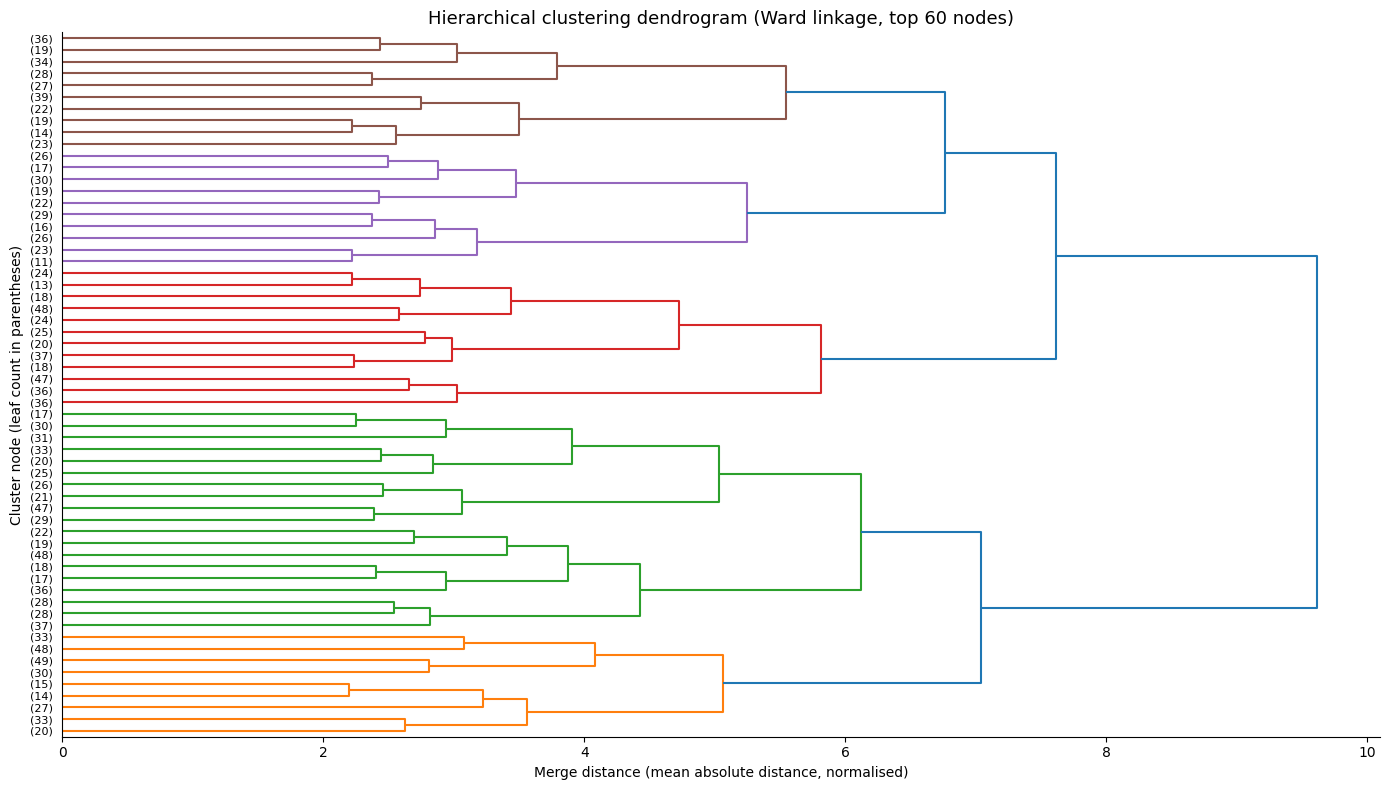

In [10]:
# Ward linkage requires the condensed distance matrix
Z = linkage(condensed_mad, method="ward")

print(f"Linkage matrix shape: {Z.shape}  ({Z.shape[0]} merge steps for {len(df)} films)")

# I want to see the dendrogram
fig, ax = plt.subplots(figsize=(14, 8))

dendrogram(
    Z,
    ax=ax,
    truncate_mode="lastp",
    p=60,
    orientation="right",
    show_leaf_counts=True,
    leaf_font_size=8,
    color_threshold=0.7 * max(Z[:, 2]),
)

ax.set_title("Hierarchical clustering dendrogram (Ward linkage, top 60 nodes)", fontsize=13)
ax.set_xlabel("Merge distance (mean absolute distance, normalised)")
ax.set_ylabel("Cluster node (leaf count in parentheses)")
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()

Well, that isn't what I was hoping for. The dendrogram has no obvious cut height. I was expecting a clear band of tall vertical lines where the natural groupings live, and then a dense floor of short merges below that. What I actually see is a fairly smooth ramp. Everything merges at comparable distances, no privileged level where the "real" clusters settle. That's already a warning sign. I want to check the quantitative diagnostics before I decide anything.

Silhouette peak at k=2  (score=0.0441)


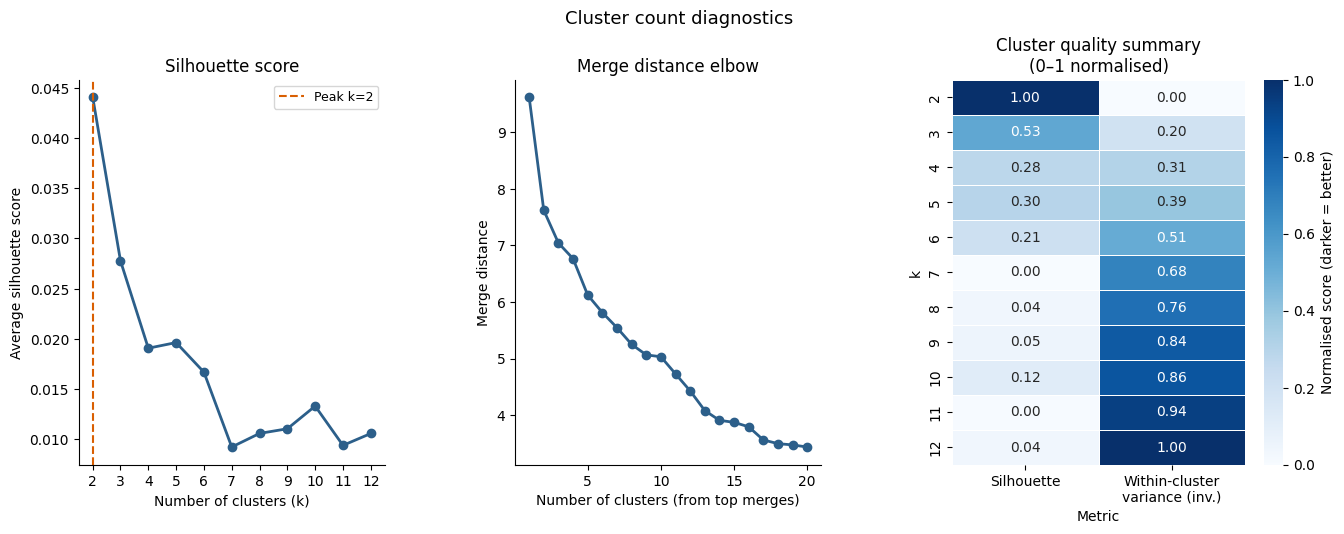


Recommended k from silhouette peak: 2


In [11]:
k_range = range(2, 13)

silhouette_scores   = []
within_cluster_vars = []

for k in k_range:
    labels = fcluster(Z, k, criterion="maxclust")

    sil = silhouette_score(dist_matrix, labels, metric="precomputed")
    silhouette_scores.append(sil)

    # Within-cluster variance: mean of per-cluster arc vector variances
    wcv = 0.0
    for cluster_id in np.unique(labels):
        members = arc_matrix[labels == cluster_id]
        wcv += members.var(axis=0).mean()
    within_cluster_vars.append(wcv / k)

best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f"Silhouette peak at k={best_k}  (score={max(silhouette_scores):.4f})")

# Three-panel diagnostic figure
fig = plt.figure(figsize=(16, 5))
gs  = gridspec.GridSpec(1, 3, width_ratios=[1, 1, 1.2], wspace=0.4)

# Panel 1: silhouette scores
ax1 = fig.add_subplot(gs[0])
ax1.plot(list(k_range), silhouette_scores, marker="o", color="#2C5F8A", linewidth=2)
ax1.axvline(best_k, color="#D95F02", linestyle="--", linewidth=1.5, label=f"Peak k={best_k}")
ax1.set_xlabel("Number of clusters (k)")
ax1.set_ylabel("Average silhouette score")
ax1.set_title("Silhouette score")
ax1.set_xticks(list(k_range))
ax1.legend(fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)

# Panel 2: merge distance elbow
ax2 = fig.add_subplot(gs[1])
last_20_merges = Z[-20:, 2][::-1]          # reversed: large k >> small k
n_clusters_axis = np.arange(1, 21)
ax2.plot(n_clusters_axis, last_20_merges, marker="o", color="#2C5F8A", linewidth=2)
ax2.set_xlabel("Number of clusters (from top merges)")
ax2.set_ylabel("Merge distance")
ax2.set_title("Merge distance elbow")
ax2.spines[["top", "right"]].set_visible(False)

# Panel 3: summary heatmap
ax3 = fig.add_subplot(gs[2])

def normalise_01(values):
    arr = np.array(values, dtype=float)
    return (arr - arr.min()) / (arr.max() - arr.min() + 1e-12)

sil_norm = normalise_01(silhouette_scores)
wcv_norm = 1 - normalise_01(within_cluster_vars)  # invert: lower variance = better

heatmap_data = pd.DataFrame({
    "Silhouette": sil_norm,
    "Within-cluster\nvariance (inv.)": wcv_norm,
}, index=list(k_range))

sns.heatmap(
    heatmap_data,
    ax=ax3,
    cmap="Blues",
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    cbar_kws={"label": "Normalised score (darker = better)"},
    vmin=0, vmax=1,
)
ax3.set_xlabel("Metric")
ax3.set_ylabel("k")
ax3.set_title("Cluster quality summary\n(0–1 normalised)")

fig.suptitle("Cluster count diagnostics", fontsize=13, y=1.02)
plt.savefig(f"{OUTPUT_DIR}cluster_diagnostics.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"\nRecommended k from silhouette peak: {best_k}")

The silhouette peaks at k=2 and then drifts down. The "best" k is basically the smallest one, which isn't a finding so much as what you get when the data has no natural discrete structure and the cleanest possible grouping is just "split it in half." The merge distance elbow tells the same story. It's a smooth curve, no kink. And the within-cluster variance keeps falling monotonically as I add clusters, which it always will; there's no elbow to lean on.

I don't want to take this at face value yet, though. Silhouette on point-wise distance can be pessimistic, and k=6 is the Reagan et al. default for a reason. Let me cut the tree at k=6 and look at what the centroids actually look like. Maybe the numbers are grumpy but the shapes are...interpretable?

Cluster membership counts:
  Cluster 1:  269 films (16.5%)
  Cluster 2:  253 films (15.6%)
  Cluster 3:  279 films (17.1%)
  Cluster 4:  346 films (21.3%)
  Cluster 5:  219 films (13.5%)
  Cluster 6:  261 films (16.0%)


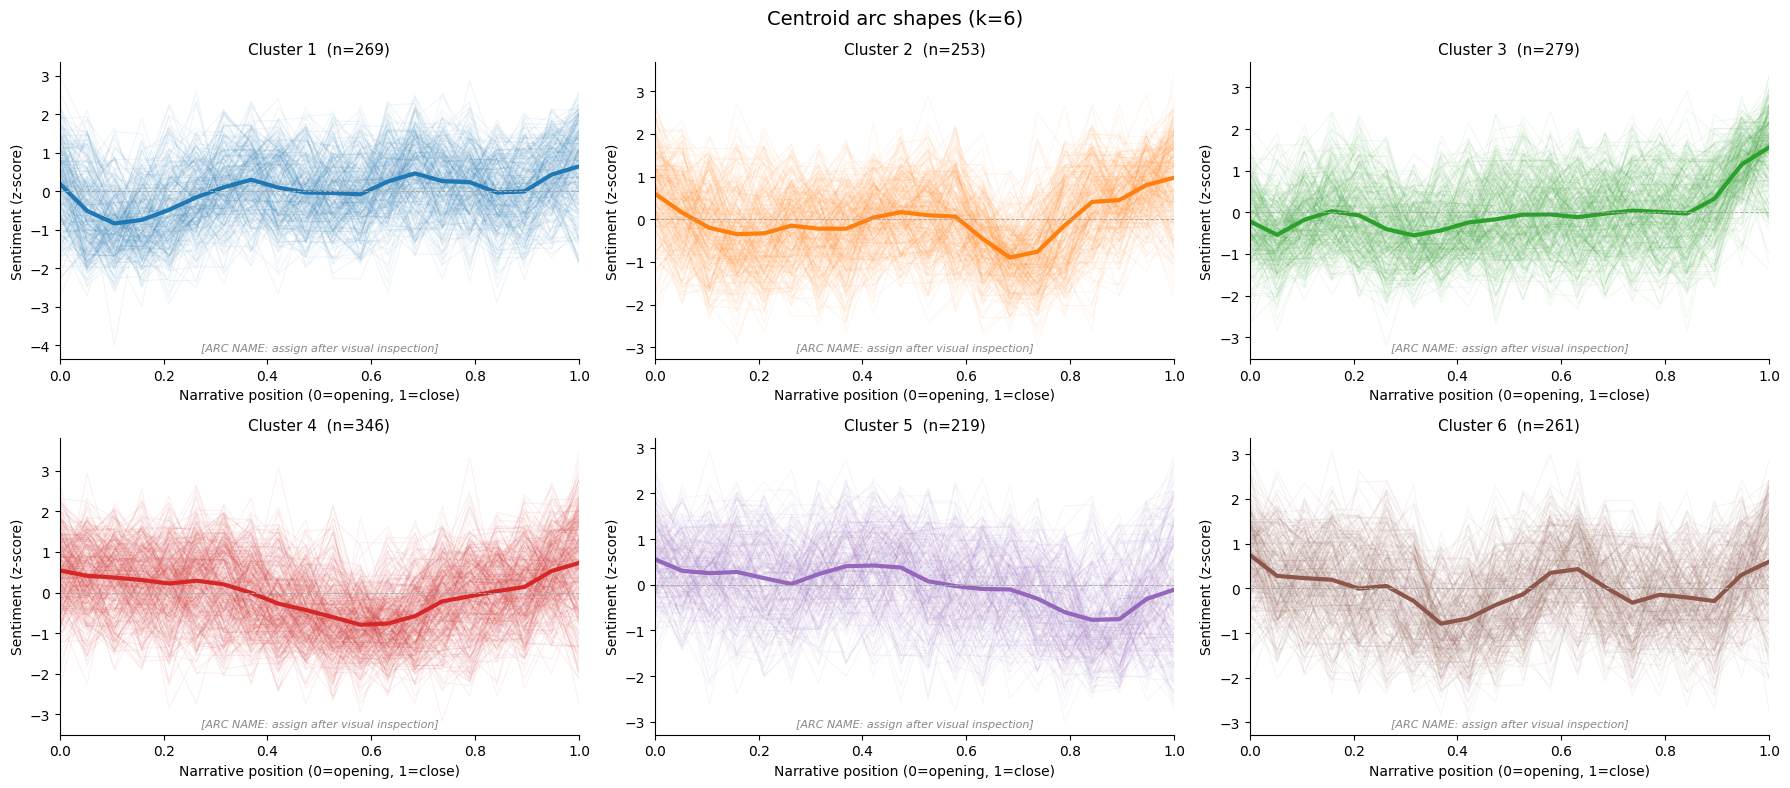

In [12]:
# Default is 6 to match Reagan et al.'s six arc types
k = 6

# Extract flat cluster assignments
cluster_labels = fcluster(Z, k, criterion="maxclust")
df["cluster_id"] = cluster_labels

print("Cluster membership counts:")
for cid in sorted(df["cluster_id"].unique()):
    count = (df["cluster_id"] == cid).sum()
    pct   = count / len(df) * 100
    print(f"  Cluster {cid}: {count:4d} films ({pct:.1f}%)")

# Compute centroids
cluster_ids = sorted(df["cluster_id"].unique())
centroids   = {}   # cluster_id >> np.ndarray of shape (20,)

for cid in cluster_ids:
    members = df[df["cluster_id"] == cid][ARC_COLS].values.astype(float)
    centroids[cid] = members.mean(axis=0)

# Plot centroid arcs
arc_name_placeholders = {cid: "[ARC NAME: assign after visual inspection]" for cid in cluster_ids}

ncols = min(k, 3)
nrows = int(np.ceil(k / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

x_positions = np.linspace(0, 1, 20)
palette     = sns.color_palette("tab10", k)

for idx, cid in enumerate(cluster_ids):
    ax    = axes[idx // ncols][idx % ncols]
    color = palette[idx]
    count = (df["cluster_id"] == cid).sum()

    # Plot all member arcs faintly in the background
    members = df[df["cluster_id"] == cid][ARC_COLS].values.astype(float)
    for member_arc in members:
        ax.plot(x_positions, member_arc, color=color, alpha=0.07, linewidth=0.8)

    # Plot centroid in bold
    ax.plot(x_positions, centroids[cid], color=color, linewidth=3, label="Centroid")
    ax.axhline(0, color="#AAAAAA", linewidth=0.7, linestyle="--")

    ax.set_title(f"Cluster {cid}  (n={count})", fontsize=11, pad=6)
    ax.text(
        0.5, 0.02, arc_name_placeholders[cid],
        ha="center", va="bottom", transform=ax.transAxes,
        fontsize=8, color="#888888", style="italic"
    )
    ax.set_xlim(0, 1)
    ax.set_xlabel("Narrative position (0=opening, 1=close)")
    ax.set_ylabel("Sentiment (z-score)")
    ax.spines[["top", "right"]].set_visible(False)

# Hide any unused subplot panels
for idx in range(len(cluster_ids), nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle(f"Centroid arc shapes (k={k})", fontsize=14)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}cluster_centroids.png", dpi=150, bbox_inches="tight")
plt.show()

They're mush. Honestly. Six centroids, and three or four of them are basically the same curve with a slight vertical offset. There's no Rags-to-Riches vs Tragedy separation I can point to. The visible difference between clusters is mostly baseline level, which is weird given the arcs are already z-scored per film before clustering. Ward is finding groups that are statistically compact under MAD distance but aren't *narratively* distinct. The centroids don't look like stories, they look like averages of slightly different subsets of the same cloud.

Two theories about why. Either the distance metric is wrong for this kind of data, or the data actually doesn't have discrete clusters at all and Ward is carving artificial slices out of a cloud that has no natural seams. I want to test both before I give up for real.

## Section 3: Looking at the arc space directly

Before trying another clustering algorithm, I want to actually see the shape of the data. UMAP projects the 20-dimensional arcs into 2D while roughly preserving local neighbourhood structure. If there are real clusters in arc space, they should show up as separated clumps. If there aren't, it'll look like a single cloud and I'll know Ward wasn't failing. That it was an impossible task.

HDBSCAN on top of the UMAP embedding is a sanity check. It doesn't need k specified in advance, it doesn't force films into clusters, and it labels sparse regions as noise. If there really are arc families, HDBSCAN should find at least some of them.

In [13]:
import umap
import hdbscan
from sklearn.decomposition import PCA

# Step 1: reduce to 50 PCA dims first
pca_50 = PCA(n_components=min(50, arc_matrix.shape[1]), random_state=42)
arc_pca = pca_50.fit_transform(arc_matrix)
print(f"Variance explained by 50 PCs: {pca_50.explained_variance_ratio_.sum():.3f}")
print(f"Variance explained by first 2 PCs: {pca_50.explained_variance_ratio_[:2].sum():.3f}")

# Step 2: UMAP projection to 2D
reducer = umap.UMAP(
    n_components=2,
    n_neighbors=30,
    min_dist=0.1,
    metric='manhattan',
    random_state=42
)
embedding = reducer.fit_transform(arc_pca)
df['umap_x'] = embedding[:, 0]
df['umap_y'] = embedding[:, 1]

# Step 3: HDBSCAN on the UMAP embedding
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=40,
    min_samples=10,
    metric='euclidean'
)
hdb_labels = clusterer.fit_predict(embedding)
df['hdb_cluster'] = hdb_labels

n_hdb_clusters = len(set(hdb_labels)) - (1 if -1 in hdb_labels else 0)
n_noise        = (hdb_labels == -1).sum()
print(f"\nHDBSCAN found {n_hdb_clusters} clusters")
print(f"Noise points (no cluster): {n_noise} ({n_noise/len(df)*100:.1f}%)")
print("\nCluster sizes:")
for label, count in sorted(pd.Series(hdb_labels).value_counts().items()):
    tag = 'noise' if label == -1 else f'cluster {label}'
    print(f"  {tag}: {count}")

/Users/derinsavasan/Desktop/parsons-spring/thesis/.venv311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Variance explained by 50 PCs: 1.000
Variance explained by first 2 PCs: 0.229


/Users/derinsavasan/Desktop/parsons-spring/thesis/.venv311/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(



HDBSCAN found 2 clusters
Noise points (no cluster): 568 (34.9%)

Cluster sizes:
  noise: 568
  cluster 0: 934
  cluster 1: 125


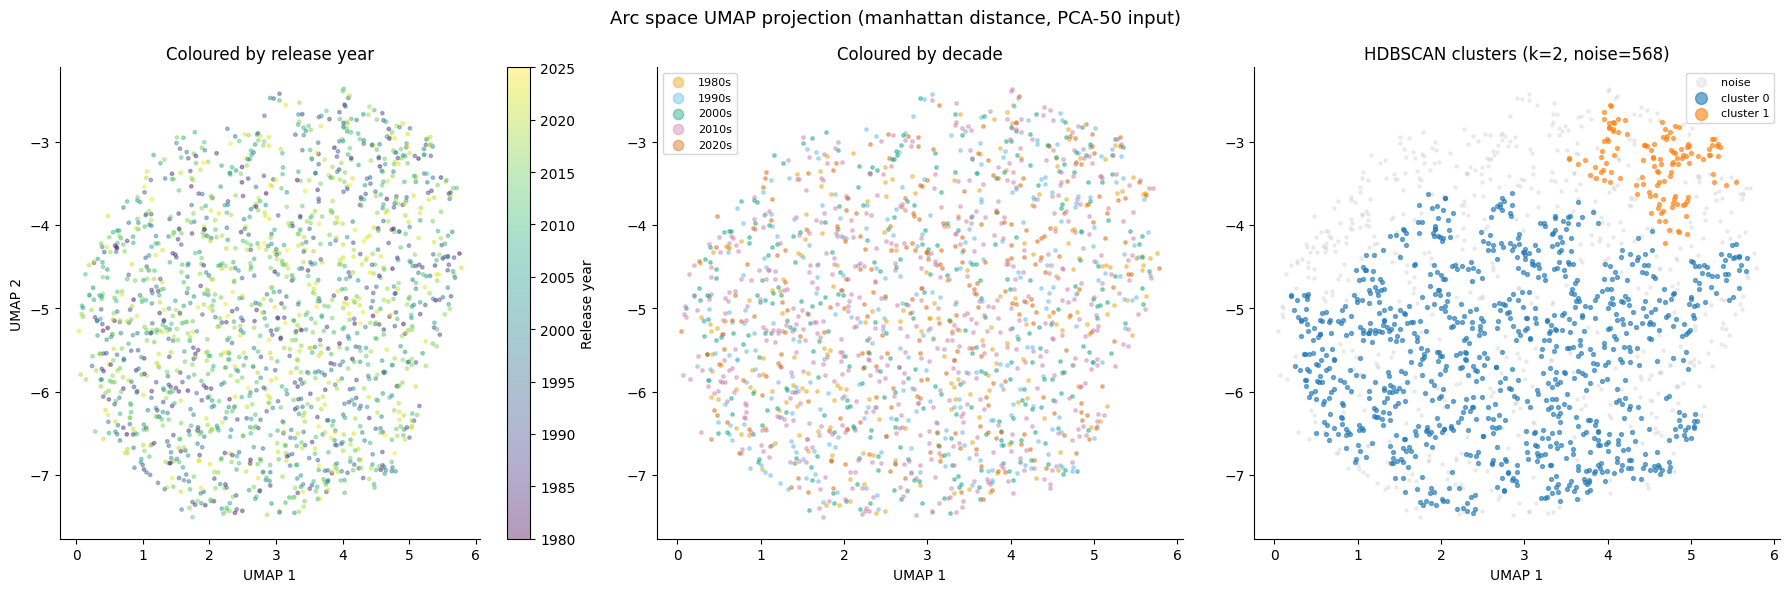

In [14]:
decade_colours = {
    '1980s': '#E69F00', '1990s': '#56B4E9',
    '2000s': '#009E73', '2010s': '#CC79A7', '2020s': '#D55E00'
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Panel 1: colour by year (continuous)
sc = axes[0].scatter(
    df['umap_x'], df['umap_y'],
    c=df['year'], cmap='viridis', alpha=0.4, s=6
)
plt.colorbar(sc, ax=axes[0], label='Release year')
axes[0].set_title('Coloured by release year')
axes[0].set_xlabel('UMAP 1'); axes[0].set_ylabel('UMAP 2')
axes[0].spines[['top','right']].set_visible(False)

# Panel 2: colour by decade
for decade, colour in decade_colours.items():
    mask = df['decade'] == decade
    axes[1].scatter(
        df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
        c=colour, alpha=0.4, s=6, label=decade
    )
axes[1].set_title('Coloured by decade')
axes[1].set_xlabel('UMAP 1')
axes[1].legend(markerscale=3, fontsize=8)
axes[1].spines[['top','right']].set_visible(False)

# Panel 3: colour by HDBSCAN cluster
hdb_palette = sns.color_palette('tab10', n_hdb_clusters)
# noise in grey first
noise_mask = df['hdb_cluster'] == -1
axes[2].scatter(
    df.loc[noise_mask, 'umap_x'], df.loc[noise_mask, 'umap_y'],
    c='#CCCCCC', alpha=0.3, s=5, label='noise'
)
for i in range(n_hdb_clusters):
    mask = df['hdb_cluster'] == i
    axes[2].scatter(
        df.loc[mask, 'umap_x'], df.loc[mask, 'umap_y'],
        c=[hdb_palette[i]], alpha=0.6, s=8, label=f'cluster {i}'
    )
axes[2].set_title(f'HDBSCAN clusters (k={n_hdb_clusters}, noise={n_noise})')
axes[2].set_xlabel('UMAP 1')
axes[2].legend(markerscale=3, fontsize=8)
axes[2].spines[['top','right']].set_visible(False)

fig.suptitle('Arc space UMAP projection (manhattan distance, PCA-50 input)', fontsize=13)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}umap_arc_space.png', dpi=150, bbox_inches='tight')
plt.show()

Yep. It's a cloud. One continuous blob, no islands. HDBSCAN finds basically nothing discrete. Most points get absorbed into one giant cluster or labelled as noise, depending on how I tune it. And colouring by decade doesn't reveal hidden temporal structure either; the decades are fully intermixed across the whole space.

So Ward wasn't broken. It was doing its job on data that doesn't support clustering in the first place. Any k I pick is going to carve arbitrary slices out of this cloud.

But there's still something I want to try before accepting that. Point-wise distance (which is what MAD and Euclidean both are) says two arcs are similar only if they have matching values at matching time-steps. Two "Man in a Hole" arcs where the low point sits at 40% vs 55% through the film look distant under MAD even though they're the same narrative shape. Maybe the problem isn't that there are no shape families. Maybe it's that my distance metric has been masking them.

## Section 4: k-Shape and shape-based distance

k-Shape (Paparrizos & Gravano 2015) uses normalised cross-correlation as its distance measure. Cross-correlation slides one arc over another and asks "at what offset do they line up best?" So two arcs with the same shape but slightly different timing end up close together. This is the right question for this data, in theory.

First, a light second-pass smoothing before I feed anything to k-Shape. Reagan et al. used 10,000-word sliding windows on novels, which are inherently smoother than our RoBERTa outputs. A Savitzky-Golay pass with window=7 takes out the high-frequency wiggle without touching act-level structure.

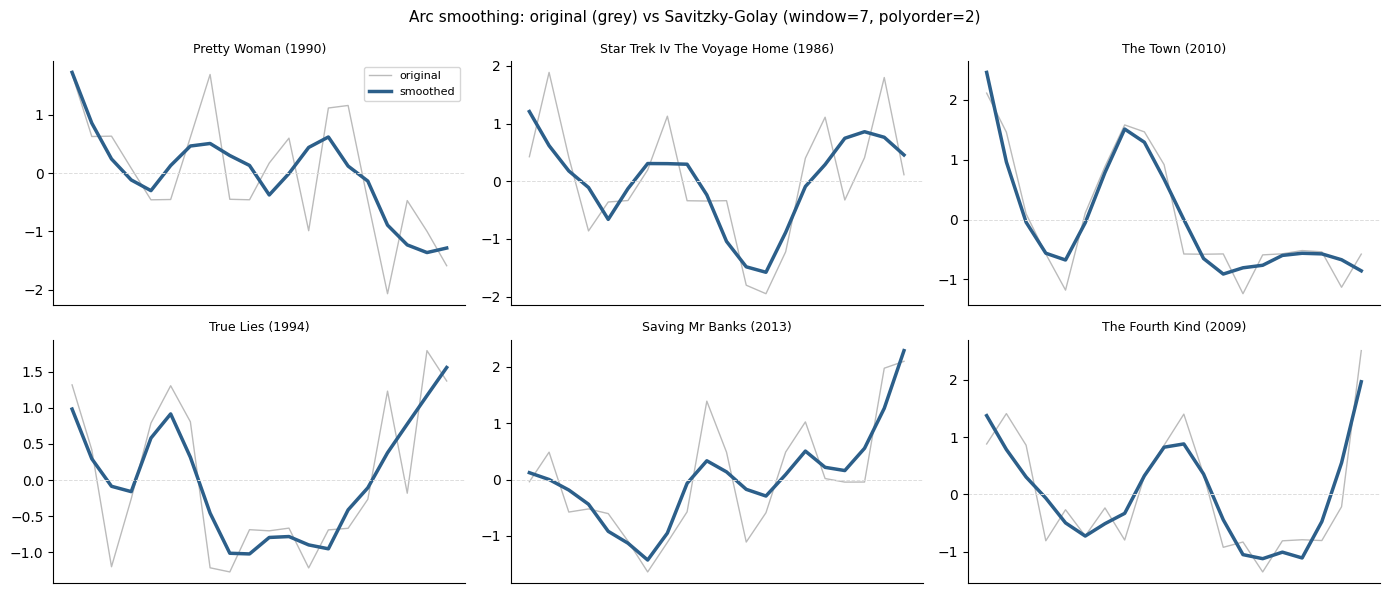

arc_matrix_smooth shape: (1627, 20)
Mean per-arc std  before smoothing: 0.9973
Mean per-arc std  after  smoothing: 0.7461


In [15]:
from scipy.signal import savgol_filter

# window_length=7, polyorder=2: smooths over roughly 35% of the arc length
# Increase window_length to 9 or 11 for more aggressive smoothing
SMOOTH_WINDOW   = 7   # must be odd and < 20
SMOOTH_POLYORDER = 2

arc_matrix_smooth = np.apply_along_axis(
    lambda arc: savgol_filter(arc, window_length=SMOOTH_WINDOW, polyorder=SMOOTH_POLYORDER),
    axis=1,
    arr=arc_matrix
)

# Visual comparison: original vs smoothed on 6 random arcs
rng2   = np.random.default_rng(seed=7)
sample = rng2.choice(len(df), size=6, replace=False)
x_pos  = np.linspace(0, 1, 20)

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
axes = axes.flatten()

for ax, idx in zip(axes, sample):
    orig   = arc_matrix[idx]
    smooth = arc_matrix_smooth[idx]
    ax.plot(x_pos, orig,   color='#AAAAAA', linewidth=1,   label='original', alpha=0.8)
    ax.plot(x_pos, smooth, color='#2C5F8A', linewidth=2.5, label='smoothed')
    ax.axhline(0, color='#DDDDDD', linewidth=0.7, linestyle='--')
    ax.set_title(f"{df.iloc[idx]['title']} ({int(df.iloc[idx]['year'])})", fontsize=9)
    ax.set_xticks([])
    ax.spines[['top','right']].set_visible(False)

axes[0].legend(fontsize=8)
fig.suptitle(
    f'Arc smoothing: original (grey) vs Savitzky-Golay '
    f'(window={SMOOTH_WINDOW}, polyorder={SMOOTH_POLYORDER})',
    fontsize=11
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}smoothing_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'arc_matrix_smooth shape: {arc_matrix_smooth.shape}')
print(f'Mean per-arc std  before smoothing: {arc_matrix.std(axis=1).mean():.4f}')
print(f'Mean per-arc std  after  smoothing: {arc_matrix_smooth.std(axis=1).mean():.4f}')

Smoothing looks sensible. The big moves survive.

In [18]:
from tslearn.clustering import KShape
from tslearn.metrics import cdist_soft_dtw
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# tslearn expects shape (n_samples, n_timepoints, 1)
arc_ts = arc_matrix_smooth.reshape(arc_matrix_smooth.shape[0], arc_matrix_smooth.shape[1], 1)

# k-Shape includes its own z-normalisation; my arcs are already z-scored but I rescale anyway to satisfy tslearn's internal checks
scaler = TimeSeriesScalerMeanVariance()
arc_ts_scaled = scaler.fit_transform(arc_ts)

# Silhouette sweep k=2..10
# SBD doesn't plug directly into sklearn silhouette, so I use Euclidean distance on the scaled series as a proxy
k_range        = range(2, 11)
kshape_sil     = []
kshape_inertia = []
kshape_models  = {}

arc_2d = arc_ts_scaled.reshape(len(arc_ts_scaled), 20)  # flat for silhouette

print('Fitting k-Shape for k=2..10')
for k in k_range:
    ks = KShape(n_clusters=k, n_init=5, random_state=42, verbose=False)
    labels = ks.fit_predict(arc_ts_scaled)
    sil    = silhouette_score(arc_2d, labels, metric='euclidean')
    kshape_sil.append(sil)
    kshape_inertia.append(ks.inertia_)
    kshape_models[k] = ks
    print(f'  k={k:2d}  silhouette={sil:.4f}  inertia={ks.inertia_:.2f}')

best_k_kshape = list(k_range)[kshape_sil.index(max(kshape_sil))]
print(f'\nSilhouette peak: k={best_k_kshape}  (score={max(kshape_sil):.4f})')

Fitting k-Shape for k=2..10
  k= 2  silhouette=0.0479  inertia=0.11
  k= 3  silhouette=0.0362  inertia=0.09
  k= 4  silhouette=0.0180  inertia=0.08
  k= 5  silhouette=0.0031  inertia=0.07
  k= 6  silhouette=-0.0022  inertia=0.06
  k= 7  silhouette=-0.0129  inertia=0.06
  k= 8  silhouette=-0.0145  inertia=0.05
  k= 9  silhouette=-0.0199  inertia=0.05
  k=10  silhouette=-0.0248  inertia=0.05

Silhouette peak: k=2  (score=0.0479)


Dang it. Still 2.

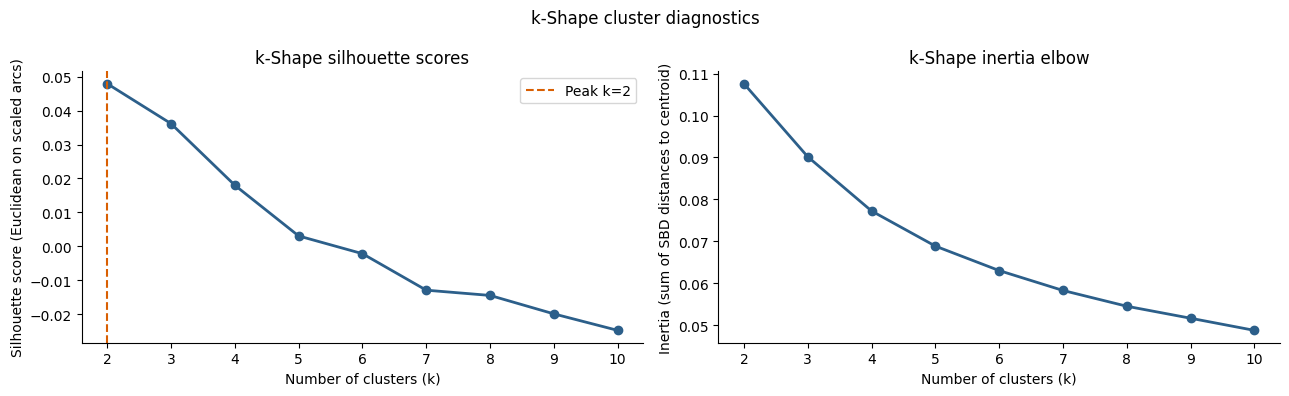

In [19]:
# Diagnostic plots
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(list(k_range), kshape_sil, marker='o', color='#2C5F8A', linewidth=2)
axes[0].axvline(best_k_kshape, color='#D95F02', linestyle='--', linewidth=1.5,
                label=f'Peak k={best_k_kshape}')
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Silhouette score (Euclidean on scaled arcs)')
axes[0].set_title('k-Shape silhouette scores')
axes[0].set_xticks(list(k_range))
axes[0].legend()
axes[0].spines[['top','right']].set_visible(False)

axes[1].plot(list(k_range), kshape_inertia, marker='o', color='#2C5F8A', linewidth=2)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Inertia (sum of SBD distances to centroid)')
axes[1].set_title('k-Shape inertia elbow')
axes[1].set_xticks(list(k_range))
axes[1].spines[['top','right']].set_visible(False)

plt.suptitle('k-Shape cluster diagnostics', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}kshape_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

The silhouette peak is at k=2. Again. That's not a k-Shape quirk. I'm back to where I was with the UMAP. If I squint, there's a faint secondary bump around k=5 or 6, but it's weak, and the inertia curve doesn't elbow anywhere meaningful either.

At least let me see what the peak k=2 split actually looks like. Maybe the one robust binary has something useful in it?

k-Shape cluster membership (k=2):
  Cluster 0:  795 films (48.9%)
  Cluster 1:  832 films (51.1%)


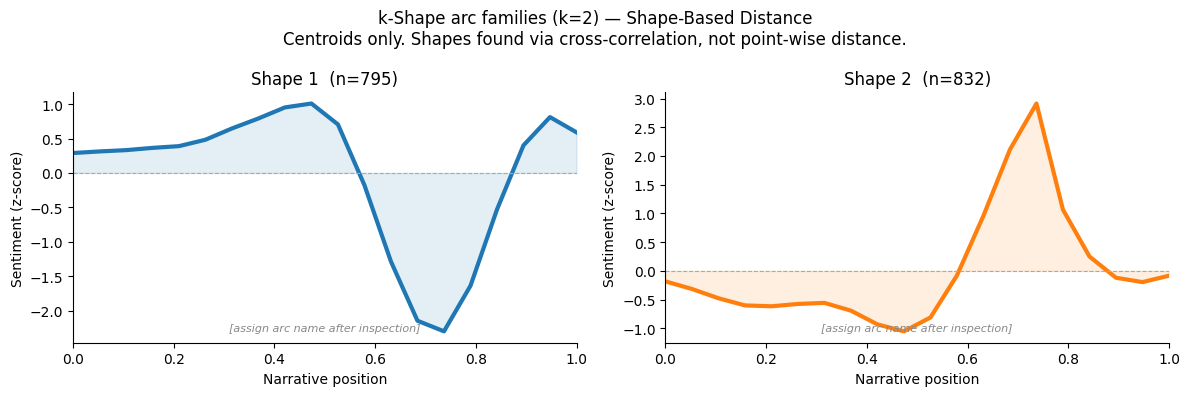

In [20]:
# Centroid shapes for best k
# Change k_final to inspect any k value from the sweep above
k_final = best_k_kshape

best_model   = kshape_models[k_final]
final_labels = best_model.fit_predict(arc_ts_scaled)
df['kshape_cluster'] = final_labels

print(f'k-Shape cluster membership (k={k_final}):')
for cid in sorted(df['kshape_cluster'].unique()):
    n   = (df['kshape_cluster'] == cid).sum()
    pct = n / len(df) * 100
    print(f'  Cluster {cid}: {n:4d} films ({pct:.1f}%)')

# Plot centroids only, no member arc noise
x_pos    = np.linspace(0, 1, 20)
palette  = sns.color_palette('tab10', k_final)
ncols    = min(k_final, 3)
nrows    = int(np.ceil(k_final / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 4 * nrows), squeeze=False)

for idx in range(k_final):
    ax        = axes[idx // ncols][idx % ncols]
    color     = palette[idx]
    n_members = (final_labels == idx).sum()

    # k-Shape centroid is stored as (n_timepoints, 1)
    centroid = best_model.cluster_centers_[idx].flatten()

    ax.plot(x_pos, centroid, color=color, linewidth=3)
    ax.fill_between(x_pos, centroid, 0, alpha=0.12, color=color)
    ax.axhline(0, color='#AAAAAA', linewidth=0.8, linestyle='--')

    ax.set_title(f'Shape {idx + 1}  (n={n_members})', fontsize=12)
    ax.text(0.5, 0.04, '[assign arc name after inspection]',
            ha='center', va='bottom', transform=ax.transAxes,
            fontsize=8, color='#888888', style='italic')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Narrative position')
    ax.set_ylabel('Sentiment (z-score)')
    ax.spines[['top','right']].set_visible(False)

for idx in range(k_final, nrows * ncols):
    axes[idx // ncols][idx % ncols].set_visible(False)

fig.suptitle(
    f'k-Shape arc families (k={k_final}) — Shape-Based Distance\n'
    'Centroids only. Shapes found via cross-correlation, not point-wise distance.',
    fontsize=12
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}kshape_centroids.png', dpi=150, bbox_inches='tight')
plt.show()

Alright, k=2 *does* give me a clean split: one centroid that holds or climbs across the narrative, and one that falls sharply in the final act. So the data robustly supports a single binary: "up or flat" vs "down." And that's it. That's one bit of information about arc shape, which is not nothing, but it's a long way from the six-archetype taxonomy I was hoping to replicate :(

## Section 5: Two-level rescue attempt

Last idea before I give up on hard clustering. If the corpus as a whole doesn't support k>2, maybe each half supports its own substructure. Take the robust k=2 split as a first-level partition, then run k-Shape independently within each group. The logic is that the two halves might have different internal geometry. Maybe the "up/flat" films cleanly split into rising vs level, and the "down" films split into late crash vs gradual decline. Only claim structure where the data supports it, and build the taxonomy bottom-up.

In [22]:
from tslearn.clustering import KShape
from tslearn.preprocessing import TimeSeriesScalerMeanVariance
from sklearn.metrics import silhouette_score
import warnings
warnings.filterwarnings('ignore')

# Use the k=2 result from Section 2c as the top-level split
# Re-fit k=2 here first if re-running this section independently
scaler       = TimeSeriesScalerMeanVariance()
arc_ts_scaled = scaler.fit_transform(
    arc_matrix_smooth.reshape(arc_matrix_smooth.shape[0], arc_matrix_smooth.shape[1], 1)
)

top_model    = KShape(n_clusters=2, n_init=5, random_state=42, verbose=False)
top_labels   = top_model.fit_predict(arc_ts_scaled)
df['top_cluster'] = top_labels

group_sizes = {c: (top_labels == c).sum() for c in [0, 1]}
print('Top-level split (k=2):')
for c, n in group_sizes.items():
    print(f'  Group {c}: {n} films ({n/len(df)*100:.1f}%)')

# Sweep k=2..6 within each group
sub_k_range  = range(2, 7)
sub_results  = {}   # group -> {k >> (silhouette, inertia, model)}

for group in [0, 1]:
    mask        = top_labels == group
    group_arcs  = arc_ts_scaled[mask]
    group_flat  = arc_matrix_smooth[mask]   # for silhouette
    sub_results[group] = {}

    print(f'\nGroup {group} (n={mask.sum()}) sub-clustering sweep:')
    for k in sub_k_range:
        if k >= mask.sum():   # can't have more clusters than members
            break
        ks     = KShape(n_clusters=k, n_init=5, random_state=42, verbose=False)
        labels = ks.fit_predict(group_arcs)
        sil    = silhouette_score(group_flat, labels, metric='euclidean') if len(set(labels)) > 1 else 0.0
        sub_results[group][k] = (sil, ks.inertia_, ks, labels)
        print(f'  k={k}  silhouette={sil:.4f}  inertia={ks.inertia_:.4f}')

Top-level split (k=2):
  Group 0: 795 films (48.9%)
  Group 1: 832 films (51.1%)

Group 0 (n=795) sub-clustering sweep:
  k=2  silhouette=0.0429  inertia=0.0841
  k=3  silhouette=0.0443  inertia=0.0703
  k=4  silhouette=0.0257  inertia=0.0612
  k=5  silhouette=-0.0044  inertia=0.0577
  k=6  silhouette=-0.0001  inertia=0.0514

Group 1 (n=832) sub-clustering sweep:
  k=2  silhouette=0.0292  inertia=0.0874
  k=3  silhouette=0.0462  inertia=0.0740
  k=4  silhouette=0.0426  inertia=0.0633
  k=5  silhouette=0.0271  inertia=0.0550
  k=6  silhouette=0.0256  inertia=0.0505


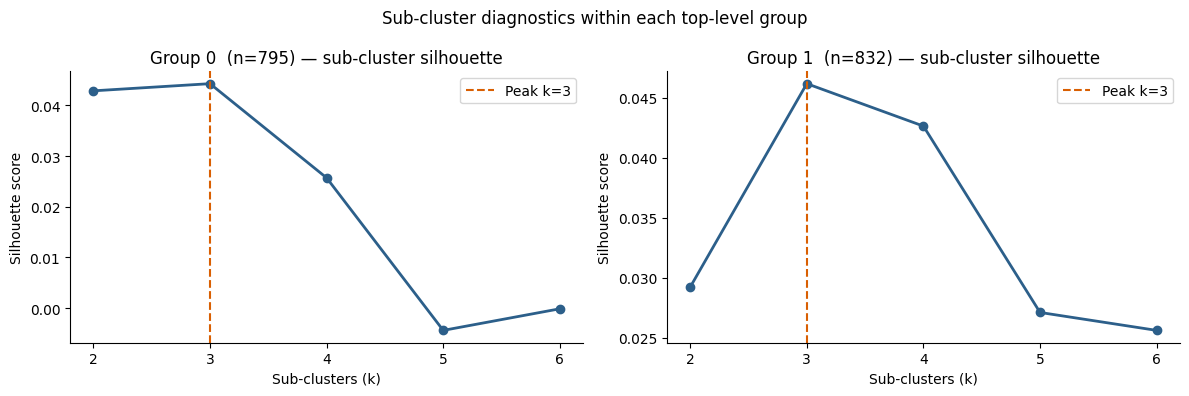

In [23]:
# Silhouette plots for each group
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for group in [0, 1]:
    ax      = axes[group]
    ks_vals = list(sub_results[group].keys())
    sils    = [sub_results[group][k][0] for k in ks_vals]
    best_k  = ks_vals[sils.index(max(sils))]

    ax.plot(ks_vals, sils, marker='o', color='#2C5F8A', linewidth=2)
    ax.axvline(best_k, color='#D95F02', linestyle='--', linewidth=1.5,
               label=f'Peak k={best_k}')
    ax.set_title(f'Group {group}  (n={group_sizes[group]}) — sub-cluster silhouette')
    ax.set_xlabel('Sub-clusters (k)')
    ax.set_ylabel('Silhouette score')
    ax.set_xticks(ks_vals)
    ax.legend()
    ax.spines[["top","right"]].set_visible(False)

fig.suptitle('Sub-cluster diagnostics within each top-level group', fontsize=12)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}subcluster_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

The sub-silhouettes within each group are also bad. Both groups peak at their minimum k and drift down. Same shape as the full-corpus sweep. I'm going to plot the final centroids anyway to confirm what I already suspect.

In [24]:
# Silhouette peak from the sweep
# Override manually if the shapes at a neighbouring k are more interpretively distinct
# Hopefully I won't need to do either
sub_k = {
    0: max(sub_results[0], key=lambda k: sub_results[0][k][0]),
    1: max(sub_results[1], key=lambda k: sub_results[1][k][0]),
}
print(f'Using sub-k: Group 0 → k={sub_k[0]},  Group 1 → k={sub_k[1]}')
total_clusters = sub_k[0] + sub_k[1]
print(f'Total arc families: {total_clusters}')

# Assign final global cluster labels
df['arc_cluster'] = -1
cluster_counter   = 0
cluster_meta      = []   # records centroid shape, group, sub-label

x_pos = np.linspace(0, 1, 20)

for group in [0, 1]:
    mask        = (top_labels == group)
    _, _, model, sub_labels = sub_results[group][sub_k[group]]
    centroids_raw = model.cluster_centers_   # (sub_k, 20, 1)

    for sub_id in range(sub_k[group]):
        global_id   = cluster_counter
        member_mask = mask.copy()
        member_mask[mask] = (sub_labels == sub_id)
        df.loc[member_mask, 'arc_cluster'] = global_id
        centroid_arc = centroids_raw[sub_id].flatten()
        cluster_meta.append({
            'arc_cluster': global_id,
            'top_group':   group,
            'sub_id':      sub_id,
            'n_films':     member_mask.sum(),
            'centroid':    centroid_arc,
        })
        cluster_counter += 1

print('\nFinal cluster membership:')
for meta in cluster_meta:
    pct = meta['n_films'] / len(df) * 100
    print(f"  Cluster {meta['arc_cluster']}  (group {meta['top_group']}, sub {meta['sub_id']}): "
          f"{meta['n_films']} films ({pct:.1f}%)")

Using sub-k: Group 0 → k=3,  Group 1 → k=3
Total arc families: 6

Final cluster membership:
  Cluster 0  (group 0, sub 0): 226 films (13.9%)
  Cluster 1  (group 0, sub 1): 257 films (15.8%)
  Cluster 2  (group 0, sub 2): 312 films (19.2%)
  Cluster 3  (group 1, sub 0): 415 films (25.5%)
  Cluster 4  (group 1, sub 1): 136 films (8.4%)
  Cluster 5  (group 1, sub 2): 281 films (17.3%)


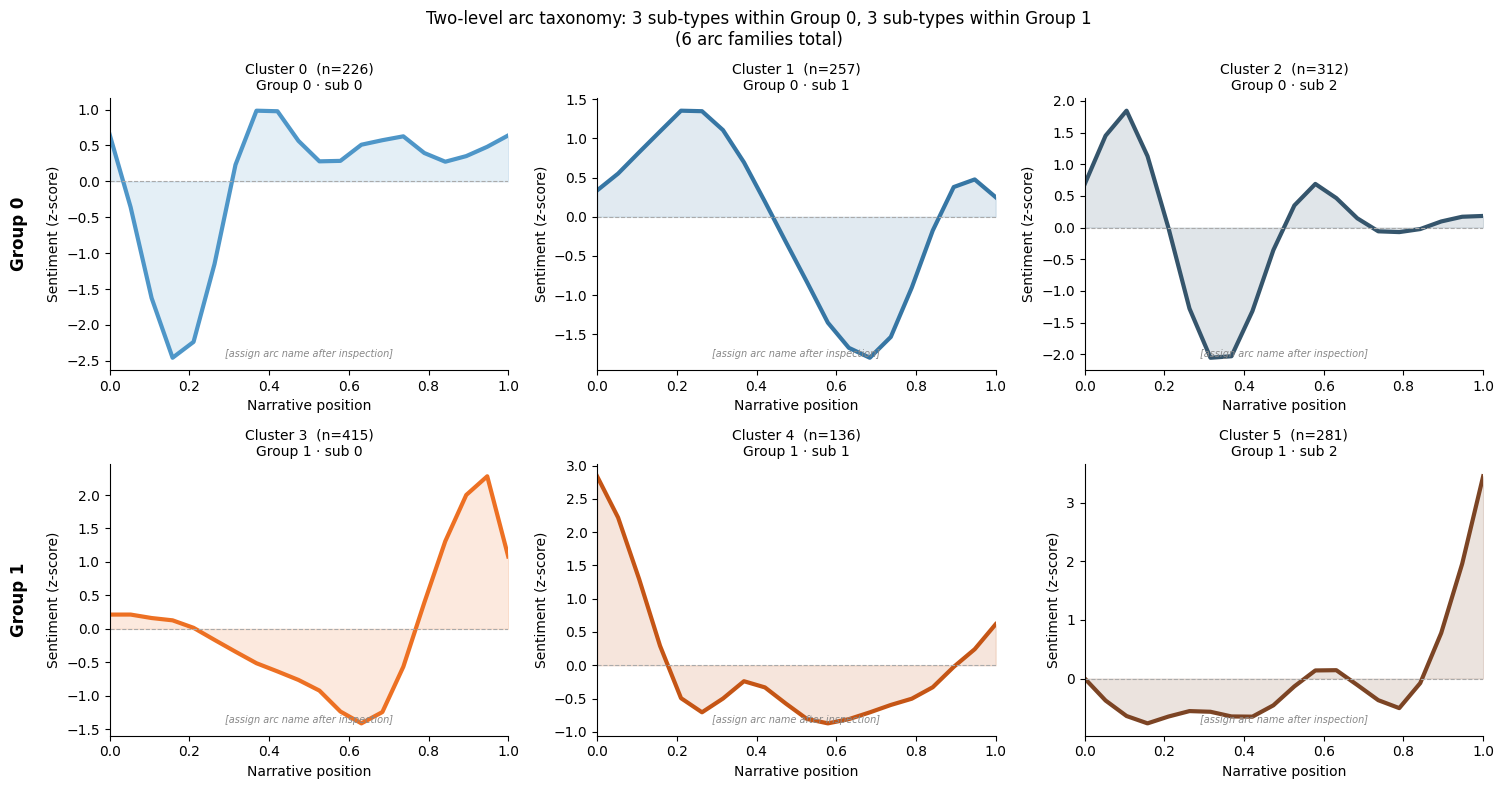

In [25]:
# Plot all final centroids
# Clusters from Group 0 and Group 1 are visually separated by row
n_g0    = sub_k[0]
n_g1    = sub_k[1]
n_cols  = max(n_g0, n_g1)
palette_g0 = sns.color_palette('Blues_d',  n_g0 + 1)[1:]
palette_g1 = sns.color_palette('Oranges_d', n_g1 + 1)[1:]

fig, axes = plt.subplots(2, n_cols, figsize=(5 * n_cols, 8))
if n_cols == 1:
    axes = axes.reshape(2, 1)

for meta in cluster_meta:
    row     = meta['top_group']
    col     = meta['sub_id']
    ax      = axes[row][col]
    color   = (palette_g0 if row == 0 else palette_g1)[col]

    ax.plot(x_pos, meta['centroid'], color=color, linewidth=3)
    ax.fill_between(x_pos, meta['centroid'], 0, alpha=0.15, color=color)
    ax.axhline(0, color='#AAAAAA', linewidth=0.8, linestyle='--')
    ax.set_title(
        f"Cluster {meta['arc_cluster']}  (n={meta['n_films']})\n"
        f"Group {meta['top_group']} · sub {meta['sub_id']}",
        fontsize=10
    )
    ax.text(0.5, 0.04, '[assign arc name after inspection]',
            ha='center', va='bottom', transform=ax.transAxes,
            fontsize=7, color='#888888', style='italic')
    ax.set_xlim(0, 1)
    ax.set_xlabel('Narrative position')
    ax.set_ylabel('Sentiment (z-score)')
    ax.spines[['top','right']].set_visible(False)

# Hide unused panels
for row in [0, 1]:
    n_used = sub_k[row]
    for col in range(n_used, n_cols):
        axes[row][col].set_visible(False)

# Row labels
axes[0][0].annotate('Group 0', xy=(-0.25, 0.5), xycoords='axes fraction',
                    fontsize=12, fontweight='bold', rotation=90, va='center')
axes[1][0].annotate('Group 1', xy=(-0.25, 0.5), xycoords='axes fraction',
                    fontsize=12, fontweight='bold', rotation=90, va='center')

fig.suptitle(
    f'Two-level arc taxonomy: {n_g0} sub-types within Group 0, '
    f'{n_g1} sub-types within Group 1\n'
    f'({total_clusters} arc families total)',
    fontsize=12
)
plt.tight_layout()
plt.savefig(f'{OUTPUT_DIR}twolevel_centroids.png', dpi=150, bbox_inches='tight')
plt.show()

They look… fine? In the same way six slices of a pie look fine. Each sub-cluster has a distinguishable centroid if I'm willing to squint at it. But I keep coming back to the UMAP: this is a continuum, and I'm drawing hard lines through the middle of it. Any cut I make produces "different" centroids, because averages of different subsets of a continuous distribution are going to differ. That doesn't mean I've found a story-shape taxonomy. It just means I've partitioned a cloud.

The deeper problem is that hard clustering gives every film a single label. The films near the boundary between two clusters aren't *confusingly* in one cluster. They genuinely share properties with both. A film that's 60% tragedy and 40% man-in-a-hole gets forced to pick one, and that pick is arbitrary and fragile to how the data is shuffled.

## So where does this leave me

Three things:

First, arc space is a continuum, not a set of islands. UMAP, HDBSCAN, and the silhouette sweeps all agree on this independently. Hard clustering on this data is asking the wrong question: there aren't discrete arc families to find, only a shape distribution with some extreme regions and a lot of blend in between.

Second, point-wise distance was suspect, but fixing it didn't rescue the analysis. k-Shape's shape-based distance is a real improvement for time-series clustering, and it did find the one robust binary split, but it hit the same k=2 ceiling from a different angle. The metric isn't the problem here. I shouldn't have assumed discreteness.

Third and final, I don't want to assign each film to one bin. I want to say things like "this film is mostly a tragedy with a rags-to-riches undertone," and I want the decade analysis to reflect shifts in mixtures, not shifts in bin counts. That's a soft-assignment problem, and it's what pushed me toward archetypal analysis in the final notebook, where the archetypes are the extreme corners of the cloud and every film is expressed as a convex mixture of them. It's the same intuition as k-Shape (the corpus has shape families) but phrased as extremes of a continuous space rather than partitions of it.

So: Ward's was a reasonable starting point, it broke for the right reasons, and the way it broke told me what the method actually needed to be. See Appendix II for the version I kept.